In [4]:
# import useful libraries
import os #fornisce funzioni per interagire con il sistema operativo
import glob #trova file con pattern specifici, tipo cerca tutti i file .jpg
import numpy as np #per il calcolo numerico
import pandas as pd #per manipolare dati tabulari tipo exel
import matplotlib.pyplot as plt #per creare e grafici e visualizzazioni di dati
import scipy.io as sio # useful because ground truth labels are uploaded as .mat files
import cv2 # per cariche e processare le immagini
import matplotlib.patches as patches #per disegnare forme sopra le immagini
from PIL import Image

In [5]:
%pwd
DATA_PATH = 'data/nunsSeg'
os.listdir(DATA_PATH)


['human bladder',
 'human brain',
 'human cardia',
 'human cerebellum',
 'human epiglottis',
 'human jejunum',
 'human kidney',
 'human liver',
 'human lung',
 'human melanoma',
 'human muscle',
 'human oesophagus',
 'human pancreas',
 'human peritoneum',
 'human placenta',
 'human pylorus',
 'human rectum',
 'human salivory gland',
 'human spleen',
 'human testis',
 'human tongue',
 'human tonsile',
 'human umbilical cord',
 'mouse fat (white and brown)_subscapula',
 'mouse femur',
 'mouse heart',
 'mouse kidney',
 'mouse liver',
 'mouse muscle_tibia',
 'mouse spleen',
 'mouse thymus',
 'paper']

In [6]:
# CONTROLLO SE NUMERO MASCHERE E IMMAGINI COINCIDONO


folders = [
    "human bladder",
    "human brain",
    "human cardia",
    "human cerebellum",
    "human epiglottis",
    "human jejunum",
    "human kidney",
    "human liver",
    "human lung",
    "human melanoma",
    "human muscle",
    "human oesophagus",
    "human pancreas",
    "human peritoneum",
    "human placenta",
    "human pylorus",
    "human rectum",
    "human salivory gland",
    "human spleen",
    "human testis",
    "human tounge",
    "human tonsile",
    "human umbilical cord",
]

image_paths = []
for folder in folders:
    image_paths += glob.glob(os.path.join(DATA_PATH, folder, "tissue images", "*.png*"))

mask_paths = []
for folder in folders:
    mask_paths += glob.glob(os.path.join(DATA_PATH, folder, "mask binary without border", "*.png"))


print(len(mask_paths))
print(len(image_paths))


432
432


In [7]:
# CONTROLLO SE MASCHERE BINARIE
# 1. maschera di esempio (1-10.png)

percorso_test = mask_paths[2]
maschera = cv2.imread(percorso_test, cv2.IMREAD_UNCHANGED)

# 2. conotrollo valori unici
valori = np.unique(maschera)

print("--- ESITO DEL TEST ---")
print(f"I valori presenti nella maschera sono: {valori}")

# 3. Interpretazione automatica
if len(valori) == 2:
    print("Confermato: Il dataset è BINARIO (solo sfondo e nuclei).")
else:
    print(f"Il dataset è MULTICLASSE (contiene {len(valori)} tipi di etichette).") 

--- ESITO DEL TEST ---
I valori presenti nella maschera sono: [  0 255]
Confermato: Il dataset è BINARIO (solo sfondo e nuclei).


In [8]:
# FUNZIONE UTILE PER ESTRARRE DATI DALLE IMMAGINI

def load_labels_from_png(mask_path):
    #Estrae metadati (inst_map, bboxes, centroids) da una maschera PNG binaria. crea una carta d'identità digitale per ogni singolo nucleo
    #IMREAD_GRAYSCALE serve a caricare l'immagine in scala di grigi.
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    num_labels, inst_map, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    # SPIEGAZIONE DEI 4 RISULTATI:
    # 1. num_labels: Un numero intero(numero nuclei +1 (che è lo sfondo che ha indice 0)). Se trova 4 nuclei, sarà 5 (perché conta anche lo sfondo!).
    # 2. inst_map: Una matrice grande come l'immagine originale. Sfondo: Il computer inizia a leggere e vede il nero. Dice: "Ok, questo è lo 0". 
        #Primo Nucleo: Incontra la prima macchia bianca. Dice: "Tutti i pixel di questa macchia d'ora in poi si chiameranno 1".
        #Secondo Nucleo: Prosegue e trova un'altra macchia separata. Dice: "Questi pixel non sono attaccati all'1, quindi sono un nuovo oggetto. Li chiamerò 2"
        #np.where(inst_map == 2),  restituirà solo ed esclusivamente le coordinate del secondo nucleo
    # 3. stats: Una tabella con 5 colonne per ogni oggetto (x, y, larghezza, altezza, area). 
        #C'è un collegamento perfetto e biunivoco (uno a uno) tra il numero del nucleo e la riga della tabella stats
        #Se nella inst_map vedi un gruppo di pixel con il numero 2, tutte le informazioni fisiche di quel gruppo si trovano nella riga 2 della tabella stats
    # 4. centroids: Una tabella con le coordinate (x, y) del centro esatto di ogni oggetto.

    #lista per i nuclei, es. np.arrange(1, 5): [1, 2, 3, 4]
    nuclei_id = np.arange(1, num_labels) 
   
        # array di "1" lungo quanto la lista dei nuclei (dataset binario, classe nuclei=1)
    classes = np.ones(len(nuclei_id), dtype=int)


    #Calcolo delle Bounding Boxes (Rettangoli)
    #da [x, y, larghezza, altezza] a [x_min, y_min, x_max, y_max].

    bboxes = []
    for i in range(1, num_labels): # no 0
        x_min, y_min, width, height, area = stats[i]
        # Calcoliamo il punto d'angolo opposto
        x_max = x_min + width
        y_max = y_min + height
        # Aggiungiamo i 4 numeri alla nostra lista
        bboxes.append([x_min, y_min, x_max, y_max]) 
        # lista in una matrice NumPy (array) -> più veloce per i calcoli
    bboxes = np.array(bboxes)
# Pulizia dei Centroidi (centroids ha anche il centro dell'immagine, togliamo)
    final_centroids = centroids[1:]

#Creazione del Dizionario e INVIO (Return) ---
    dict_labels = {
        'inst_map': inst_map,         # La matrice con i numeri ID
        'nuclei_id': nuclei_id,       # La lista [1, 2, 3...]
        'classes': classes,           # La lista [1, 1, 1...]
        'bboxs': bboxes,              # I rettangoli [x_min, y_min, x_max, y_max]
        'centroids': final_centroids  # I punti centrali (x, y)
    }
    
    return dict_labels

In [9]:
# VERIFICA NUCLEI TORVATI NELLA PRIMA IMMAGINE
percorso_della_mia_maschera = mask_paths[0] 

label = load_labels_from_png(percorso_della_mia_maschera)
print("Informazioni disponibili:", label.keys()) 
# Estrai la matrice dei centroidi
centroids = label['centroids']

# Verifica quanti nuclei sono stati trovati
print(f"Numero di nuclei rilevati: {len(centroids)}") 



Informazioni disponibili: dict_keys(['inst_map', 'nuclei_id', 'classes', 'bboxs', 'centroids'])
Numero di nuclei rilevati: 23


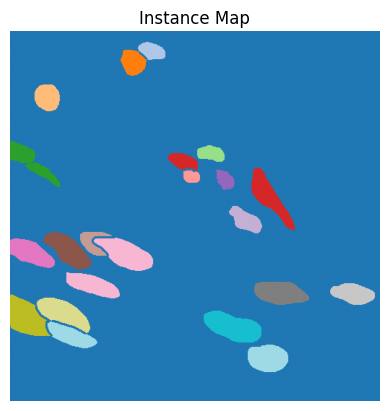

In [10]:
# ESEMPIO INSTANCE MASK, mappa colori categorica
inst_map = label['inst_map'] 
bboxs = label['bboxs']
nuclei_id = label['nuclei_id']
centroids = label['centroids']
classes = label ['classes']
# variabili singole più facili da manipolare

plt.imshow(inst_map, cmap="tab20") 
plt.title("Instance Map") 
plt.axis("off") 
plt.show() 

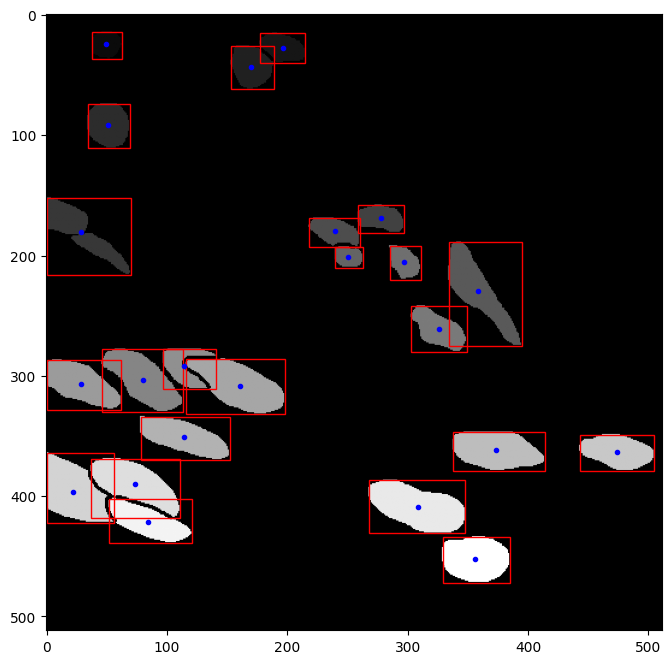

In [11]:
# 2. GRAFICO BOUNDING BOXES E CENTROIDS
fig, ax = plt.subplots(figsize=(8,8)) 
ax.imshow(inst_map, cmap="gray") #Carica la mappa dei nuclei come sfondo (GRIGIO)
for idx, nucleus_id in enumerate(nuclei_id): 
    x1, y1, x2, y2 = bboxs[idx] 
    cx, cy = centroids[idx]  
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height,
                             linewidth=1, edgecolor="r", facecolor="none") 
    # la funzione rect in input riceve rispettivamente (punto di partenza, larghezza (x2-x1) e altezza (y2-y1)) 
    #edgecolor="r": r sta per Red (Rosso). Disegna il contorno.
    #facecolor="none" dice di non colorare l'interno del rettangolo
    ax.add_patch(rect)

    ax.plot(cx, cy, "bo", markersize=3) #bo": Sta per Blue Object ( cerchietto blu). ## densità nuclei

plt.show()



In [12]:
data_images = []

for img_path, mask_path in zip(image_paths, mask_paths):

    # RGB PER IMMAGINE
    img = np.array(Image.open(img_path))

    if img.ndim == 3:
        R = img[:,:,0].flatten()[::10]
        G = img[:,:,1].flatten()[::10]
        B = img[:,:,2].flatten()[::10]

        R_mean = np.mean(R)
        G_mean = np.mean(G)
        B_mean = np.mean(B)

        R_std = np.std(R)
        G_std = np.std(G)
        B_std = np.std(B)

    # NUCLEI E DENSITÀ

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    num_labels, _ = cv2.connectedComponents(binary)
    n_nuclei = num_labels - 1

    area = mask.shape[0] * mask.shape[1]
    density = n_nuclei / area

    # SALVA TUTTO
    
    data_images.append({
        "image_id": os.path.basename(img_path),
        "mask_id": os.path.basename(mask_path),
        "nuclei": n_nuclei,
        "density": density,
        "R_mean": R_mean,
        "G_mean": G_mean,
        "B_mean": B_mean,
        "R_std": R_std,
        "G_std": G_std,
        "B_std": B_std
    })

df_images = pd.DataFrame(data_images)

print(df_images.head())

               image_id               mask_id  nuclei   density      R_mean  \
0  human_bladder_01.png  human_bladder_01.png      23  0.000088  103.158955   
1  human_bladder_02.png  human_bladder_02.png       3  0.000011  124.014839   
2  human_bladder_03.png  human_bladder_03.png      25  0.000095  107.094221   
3  human_bladder_04.png  human_bladder_04.png     118  0.000450   82.676445   
4  human_bladder_05.png  human_bladder_05.png      28  0.000107  111.994888   

       G_mean      B_mean      R_std      G_std      B_std  
0   96.729010  120.316269  27.151547  27.063437  16.550248  
1  120.135152  132.406294  23.383102  24.552251  16.097912  
2   95.883464  120.899523  18.958860  16.665713  11.370204  
3   79.088270  108.768758  36.299109  36.790403  23.436942  
4  102.584551  124.816479  21.181556  19.577989  12.165011  


In [13]:
data_nuclei = []

for mask_path in mask_paths:
    labels = load_labels_from_png(mask_path)

    for i, nucleus_id in enumerate(labels["nuclei_id"]):
        bbox = labels["bboxs"][i]
        centroid = labels["centroids"][i]

        data_nuclei.append({
            "image_id": os.path.basename(mask_path),
            "nucleus_id": nucleus_id,
            "x_min": bbox[0],
            "y_min": bbox[1],
            "x_max": bbox[2],
            "y_max": bbox[3],
            "centroid_x": centroid[0],
            "centroid_y": centroid[1]
        })

df_nuclei = pd.DataFrame(data_nuclei)

print(df_nuclei.head())

               image_id  nucleus_id  x_min  y_min  x_max  y_max  centroid_x  \
0  human_bladder_01.png           1     38     14     63     37   49.497788   
1  human_bladder_01.png           2    177     15    215     40  196.135417   
2  human_bladder_01.png           3    153     26    189     62  169.881607   
3  human_bladder_01.png           4     34     74     69    111   51.233175   
4  human_bladder_01.png           5      0    152     70    216   28.598170   

   centroid_y  
0   24.601770  
1   27.270833  
2   42.951374  
3   91.450237  
4  180.463758  


In [14]:
df_dataset = pd.DataFrame([{
    "num_images": len(image_paths),
    "num_masks": len(mask_paths),
    "mean_nuclei_per_image": df_images["nuclei"].mean(),
    "mean_density": df_images["density"].mean(),
    "R_mean_dataset": df_images["R_mean"].mean(),
    "G_mean_dataset": df_images["G_mean"].mean(),
    "B_mean_dataset": df_images["B_mean"].mean()
}])

print(df_dataset)

   num_images  num_masks  mean_nuclei_per_image  mean_density  R_mean_dataset  \
0         432        432               46.00463      0.000175       110.19952   

   G_mean_dataset  B_mean_dataset  
0       70.895409      100.308029  


In [15]:
# NUMERI TOTALI NUCLEI E MEDIA NUCLEI PER IMMAGINE

print(f"Nuclei totali nel dataset:", df_images["nuclei"].sum())
print(f"Media di nuclei per immagine: ", df_images["nuclei"].mean() )

Nuclei totali nel dataset: 19874
Media di nuclei per immagine:  46.004629629629626


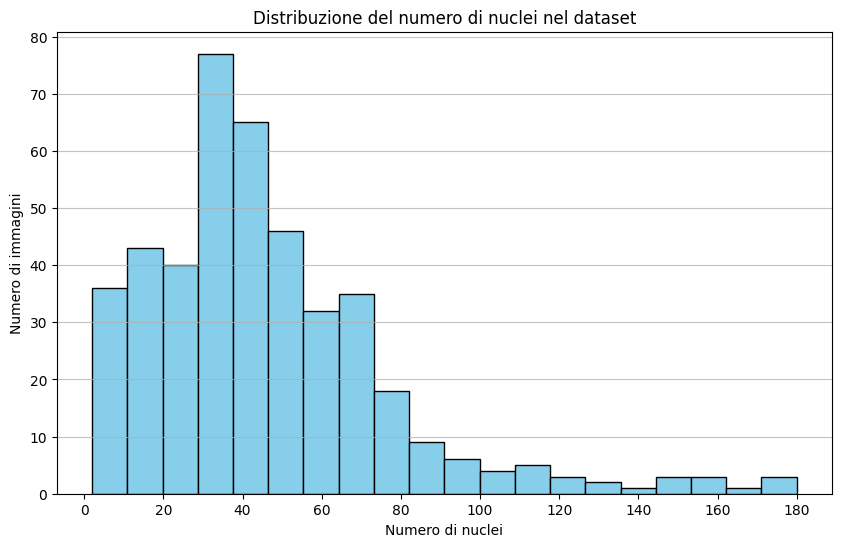

In [16]:
# GRAFICO DISTRIBUZIONE NUCLEI NELLE IMMAGINI

plt.figure(figsize=(10, 6))
plt.hist(df_images["nuclei"], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuzione del numero di nuclei nel dataset')
plt.xlabel('Numero di nuclei')
plt.ylabel('Numero di immagini')
plt.xticks(np.arange(0, df_images["nuclei"].max() + 20, 20))
plt.grid(axis='y', alpha=0.75)
plt.savefig("hist_images_VS_nuclei_Nuinsseg.png", dpi=300)

plt.show() 

In [17]:
# DENSITà MEDIA E DEVIAZIONE STANDARD

print(f"densità media:", df_images["density"].mean())
print(f"deviazione standard: ", df_images["density"].std() )




densità media: 0.000175493734854239
deviazione standard:  0.0001189350314666418


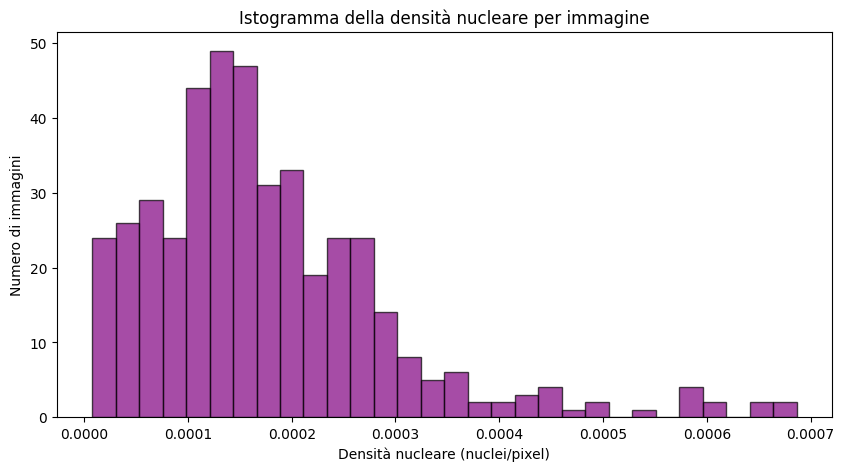

In [18]:
# ISOGRAMMA DENSITà NUCLEARE (NUCLEO/PIXEL)

plt.figure(figsize=(10,5))
plt.hist(df_images["density"], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title("Istogramma della densità nucleare per immagine")
plt.xlabel("Densità nucleare (nuclei/pixel)")
plt.ylabel("Numero di immagini")
plt.savefig("hist_images_VS_density_Nuinsseg.png", dpi=300)

plt.show()

In [19]:
def analyze_masks(mask_folder):
    mask_paths = glob.glob(os.path.join(mask_folder, "*.png"))
    nuclei_counts = []
    densities = []

    for mask_path in mask_paths:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue  # evita file corrotti

        # binarizza
        _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        # componenti connesse
        num_labels, _ = cv2.connectedComponents(binary)

        nuclei_counts.append(num_labels - 1)

        area = mask.shape[0] * mask.shape[1]
        densities.append((num_labels - 1) / area)

    return nuclei_counts, densities

In [20]:
import numpy as np
import pandas as pd
import os
import glob

results = []

for folder in folders:
    mask_folder = os.path.join(DATA_PATH, folder, "mask binary without border")
    _, densities = analyze_masks(mask_folder)
    
    if len(densities) > 0:
        mean_density = np.mean(densities)
        std_density = np.std(densities)
        n_images = len(densities)
        results.append([folder, mean_density, std_density, n_images])

df_summary = pd.DataFrame(results, columns=["Tissue", "MeanDensity", "StdDensity", "N_images"])
df_summary = df_summary.sort_values("MeanDensity", ascending=False)
print(df_summary)

                  Tissue  MeanDensity  StdDensity  N_images
6           human kidney     0.000352    0.000081        11
18          human spleen     0.000323    0.000212        34
20         human tonsile     0.000315    0.000089        12
5          human jejunum     0.000266    0.000086        10
17  human salivory gland     0.000244    0.000057        44
2           human cardia     0.000200    0.000139        12
12        human pancreas     0.000182    0.000039        44
14        human placenta     0.000167    0.000060        40
9         human melanoma     0.000162    0.000051        12
3       human cerebellum     0.000158    0.000178        12
11      human oesophagus     0.000150    0.000074        47
13      human peritoneum     0.000145    0.000062        12
15         human pylorus     0.000136    0.000048        12
7            human liver     0.000125    0.000031        40
0          human bladder     0.000121    0.000105        12
19          human testis     0.000117   

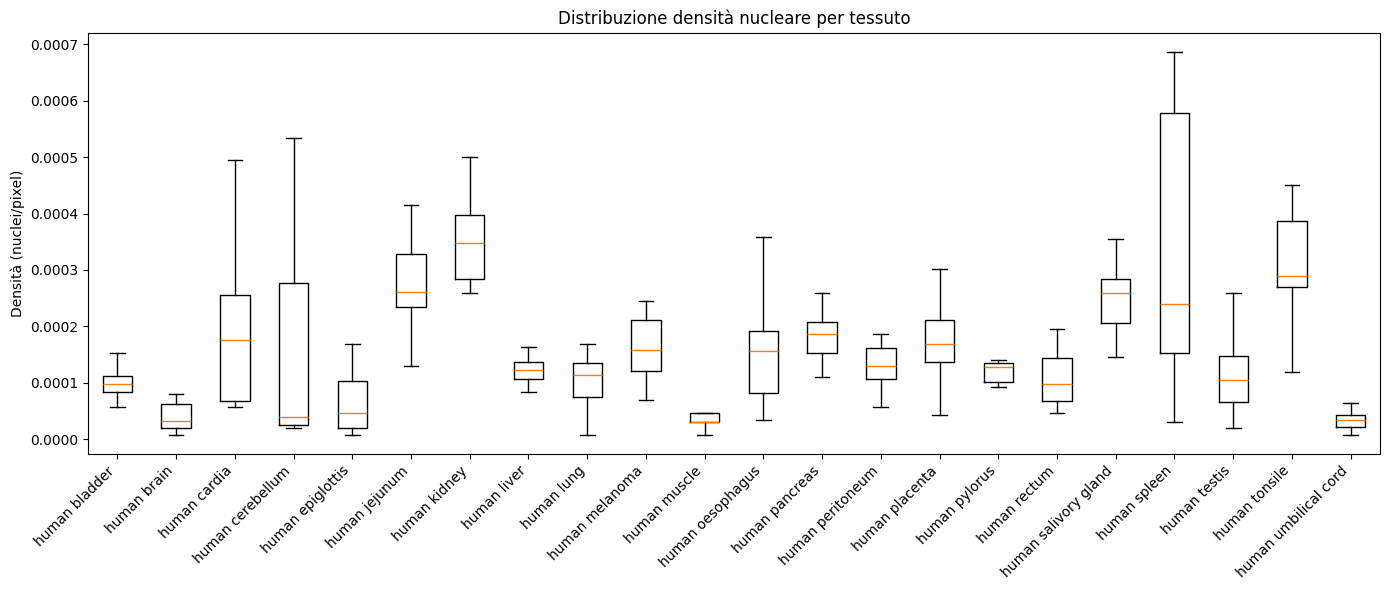

In [21]:
# BOXPLOT DENSITà

all_densities = []
labels = []

for folder in folders:
    mask_folder = os.path.join(DATA_PATH, folder, "mask binary without border")
    _, densities = analyze_masks(mask_folder)
    
    if len(densities) > 0:  # evita folder vuoti
        all_densities.append(densities)
        labels.append(folder)

plt.figure(figsize=(14,6))
plt.boxplot(all_densities, tick_labels=labels, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title("Distribuzione densità nucleare per tessuto")
plt.ylabel("Densità (nuclei/pixel)")
plt.tight_layout()
plt.savefig("boxplot_images_VS_density_Nuinsseg.png", dpi=300)

plt.show()

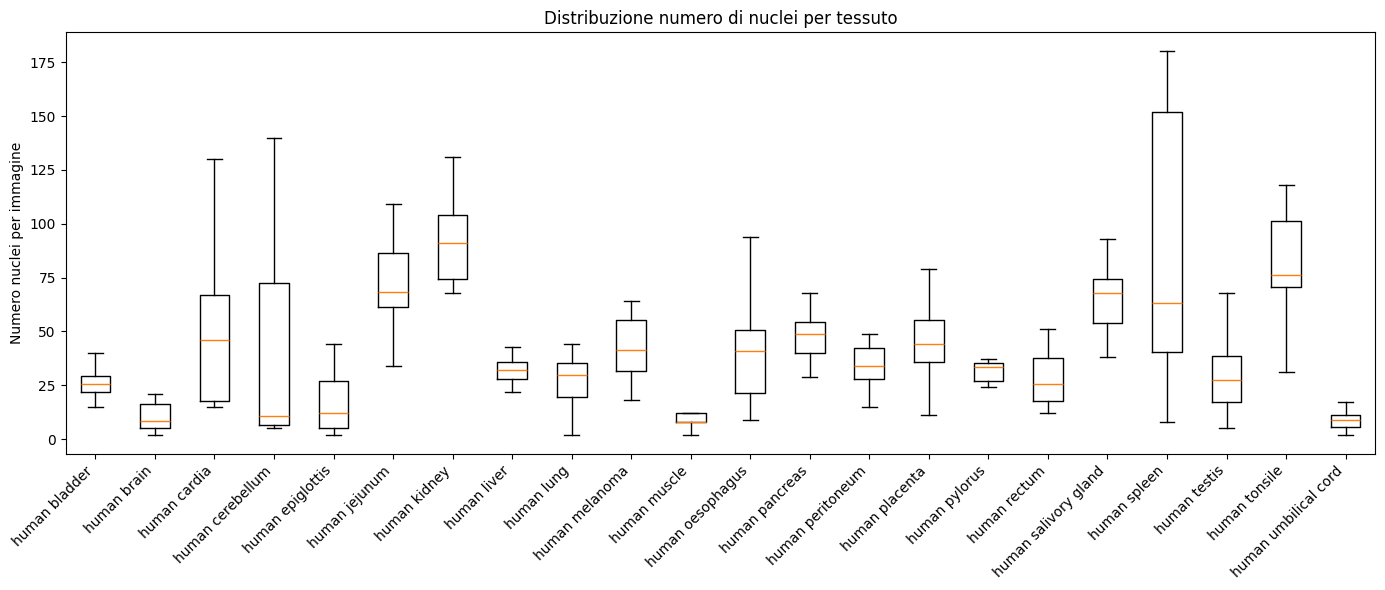

In [22]:
#BOXPLOT IN BASE AL NUMERO DI NUCLEI


all_counts = []
labels = []

for folder in folders:
    mask_folder = os.path.join(DATA_PATH, folder, "mask binary without border")
    counts, _ = analyze_masks(mask_folder)
    
    if len(counts) > 0:
        all_counts.append(counts)
        labels.append(folder)

plt.figure(figsize=(14,6))
plt.boxplot(all_counts, tick_labels=labels, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title("Distribuzione numero di nuclei per tessuto")
plt.ylabel("Numero nuclei per immagine")
plt.tight_layout()
plt.savefig("boxplot_images_VS_nuclei_Nuinsseg.png", dpi=300)

plt.show()

In [23]:
# TEST ANOVA
from scipy.stats import f_oneway

# ANOVA
f_stat, p_value = f_oneway(*all_counts)

print("ANOVA results:")
print("F-statistic:", f_stat)
print("p-value:", p_value)

# p< 0.05 almeno un gruppo è significativamente diverso 
# HO DIFFERENZE FORTI TRA I TESSUTI

ANOVA results:
F-statistic: 15.113370482720349
p-value: 3.763497499871869e-39


In [24]:
# TEST KRUSKAL-WALLIS
from scipy.stats import kruskal

h_stat, p_value = kruskal(*all_counts)

print("Kruskal-Wallis results:")
print("H-statistic:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis results:
H-statistic: 215.356322036315
p-value: 3.361544532674193e-34


In [27]:
!pip install scikit-posthocs
import scikit_posthocs as sp
import pandas as pd

# prepara i dati in formato lungo
data = []
for label, counts in zip(labels, all_counts):
    for c in counts:
        data.append([label, c])

df = pd.DataFrame(data, columns=["tissue", "count"])

# Dunn test con correzione Bonferroni
dunn = sp.posthoc_dunn(df, val_col="count", group_col="tissue", p_adjust='bonferroni')

print(dunn)

##	human kidney vs human bladder → 0.000094 → significativo (diversi)
#	•	human jejunum vs human brain → 2.808784e-05 → significativo
#	•	human bladder vs human liver → 1.0 → non significativo (simili) 

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 13.0 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.6 MB 13.6 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 13.8 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 12.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [patsy]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   --------

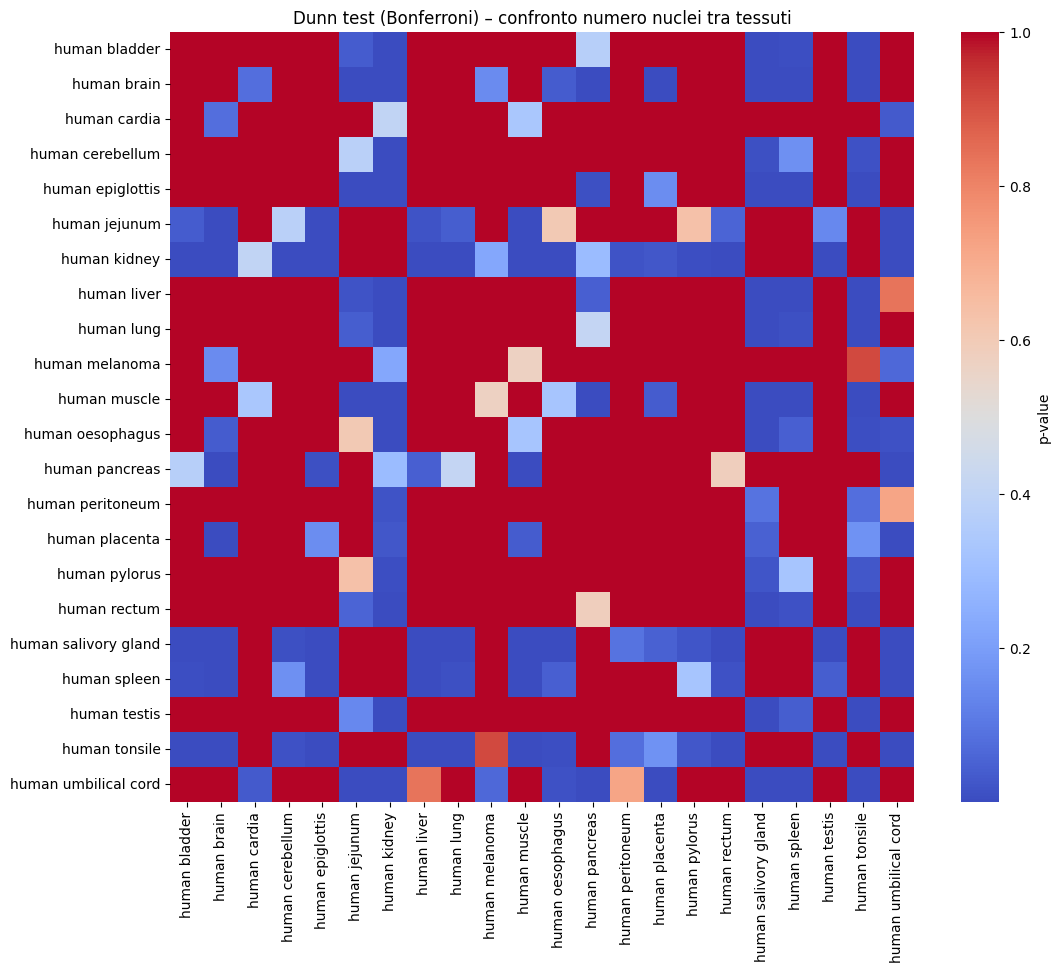

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(dunn,  fmt=".3f", cmap="coolwarm", cbar_kws={'label': 'p-value'})
plt.title("Dunn test (Bonferroni) – confronto numero nuclei tra tessuti")
plt.savefig("dunntest_nuclei_VS_tissues_Nuinsseg.png", dpi=300)

plt.show() 

In [29]:
# ANALISI RGB


# array vuoti per ogni canale
R_values = []
G_values = []
B_values = []

# loop su tutte le immagini
for img_path in image_paths:
    img = Image.open(img_path)          # apri immagine
    img = np.array(img)                  # conversione in array numpy
    if img.ndim == 3:                    # RGB
        R_values.extend(img[:,:,0].flatten()[::10])
        G_values.extend(img[:,:,1].flatten()[::10])
        B_values.extend(img[:,:,2].flatten()[::10])

# Statistiche RGB

R_mean = np.mean(R_values)
G_mean = np.mean(G_values)
B_mean = np.mean(B_values)

R_std = np.std(R_values)
G_std = np.std(G_values)
B_std = np.std(B_values)

print("📊 STATISTICHE RGB\n")

print("🔴 Red  -> Media:", R_mean, " | Deviazione standard:", R_std)
print("🟢 Green-> Media:", G_mean, " | Deviazione standard:", G_std)
print("🔵 Blue -> Media:", B_mean, " | Deviazione standard:", B_std) 

📊 STATISTICHE RGB

🔴 Red  -> Media: 110.19952017151617  | Deviazione standard: 26.247442954501345
🟢 Green-> Media: 70.89540886967455  | Deviazione standard: 28.63110332746848
🔵 Blue -> Media: 100.30802895924725  | Deviazione standard: 20.405714268575725


                  R             G             B
count  1.132488e+07  1.132488e+07  1.132488e+07
mean   1.101995e+02  7.089541e+01  1.003080e+02
std    2.624744e+01  2.863110e+01  2.040572e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    9.500000e+01  5.000000e+01  8.700000e+01
50%    1.140000e+02  6.800000e+01  9.900000e+01
75%    1.290000e+02  8.900000e+01  1.150000e+02
max    1.910000e+02  1.720000e+02  1.760000e+02


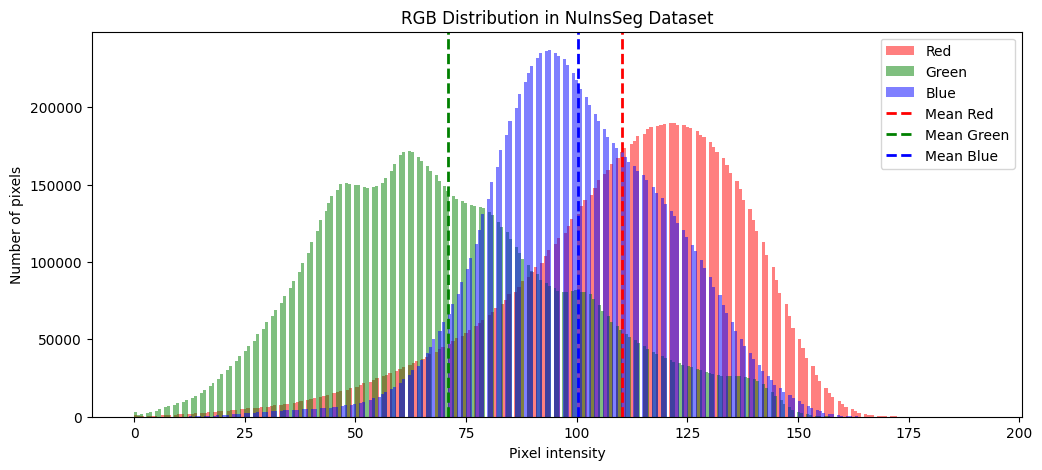

In [46]:
df = pd.DataFrame({
    'R': R_values,
    'G': G_values,
    'B': B_values
})

print(df.describe())

plt.figure(figsize=(12,5))

plt.hist(R_values, bins=256, color='red', alpha=0.5, label='Red')
plt.hist(G_values, bins=256, color='green', alpha=0.5, label='Green')
plt.hist(B_values, bins=256, color='blue', alpha=0.5, label='Blue')

plt.axvline(R_mean, color='red', linestyle='dashed', linewidth=2, label='Mean Red')
plt.axvline(G_mean, color='green', linestyle='dashed', linewidth=2, label='Mean Green')
plt.axvline(B_mean, color='blue', linestyle='dashed', linewidth=2, label='Mean Blue')


plt.title("RGB Distribution in NuInsSeg Dataset")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.legend()
plt.savefig("hist_RGB_distribuition_Nuinsseg.png", dpi=300)
plt.show()  

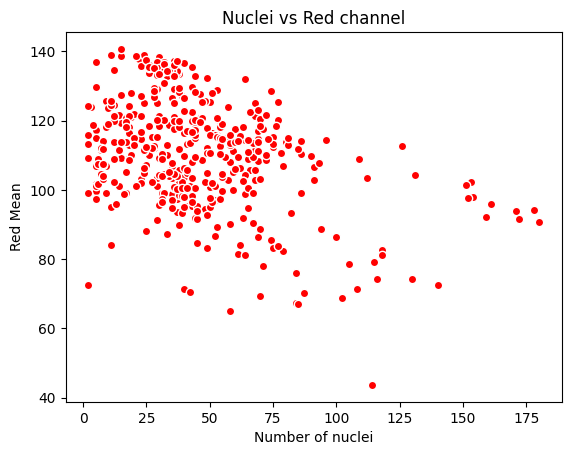

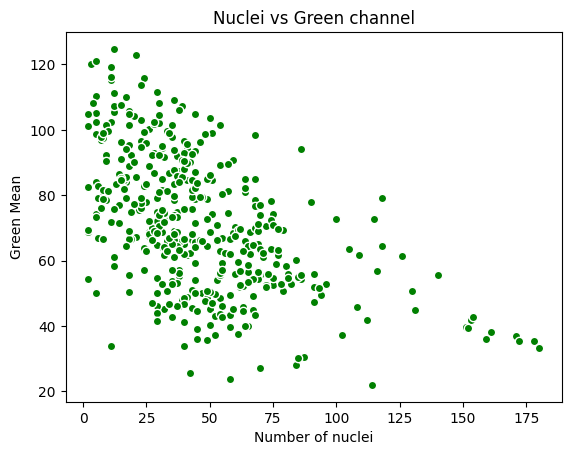

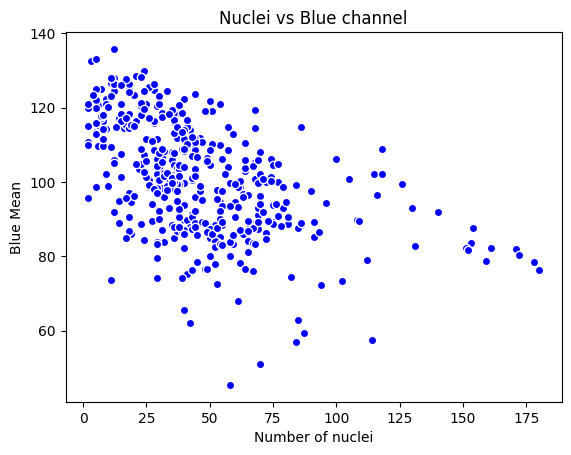

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_images["nuclei"], df_images["R_mean"], edgecolor='white', color= 'red')
plt.xlabel("Number of nuclei")
plt.ylabel("Red Mean")
plt.title("Nuclei vs Red channel")
plt.savefig("scatter_nuclei_VS_red_Nuinsseg.png", dpi=300)

plt.show()

plt.figure()
plt.scatter(df_images["nuclei"], df_images["G_mean"], edgecolor='white', color= 'green')
plt.xlabel("Number of nuclei")
plt.ylabel("Green Mean")
plt.title("Nuclei vs Green channel")
plt.savefig("scatter_nuclei_VS_green_Nuinsseg.png", dpi=300)
plt.show()

plt.figure()
plt.scatter(df_images["nuclei"], df_images["B_mean"], edgecolor='white', color= 'blue')
plt.xlabel("Number of nuclei")
plt.ylabel("Blue Mean")
plt.title("Nuclei vs Blue channel")
plt.savefig("scatter_nuclei_VS_blue_Nuinsseg.png", dpi=300)
plt.show() 

In [32]:
df_images.to_csv("df_images_Nuinsseg.csv", index=False)
df_nuclei.to_csv("df_nuclei_Nuinsseg.csv", index=False)
df_dataset.to_csv("df_dataset_Nuinsseg.csv", index=False)
df_summary.to_csv("df_tissue_summary_Nuinsseg.csv", index=False) 

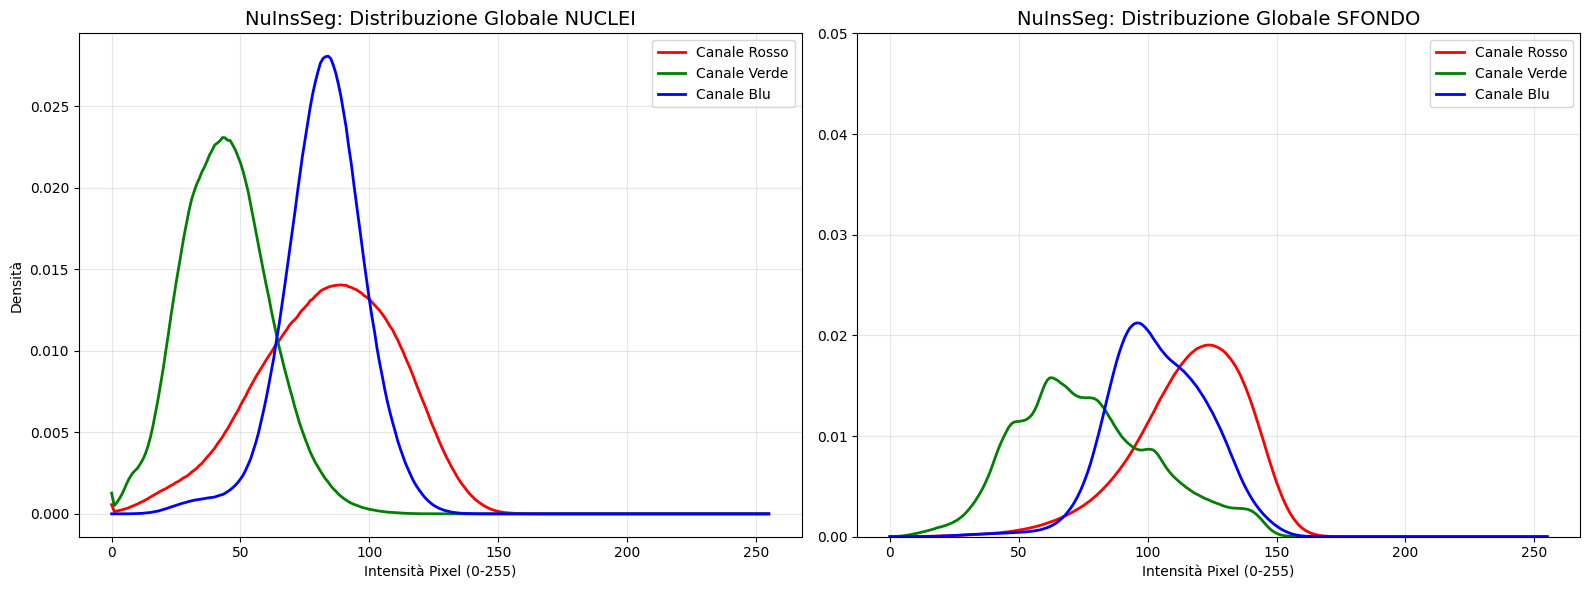

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# --- 1. INIZIALIZZAZIONE ---


# Creiamo i contenitori per i conteggi dei pixel (256 livelli per 3 canali RGB)
hist_global_nuclei = np.zeros((256, 3))
hist_global_bg = np.zeros((256, 3))

# --- 2. CICLO DI CALCOLO ---
for i in range(len(image_paths)):
    # Caricamento immagine (RGB) e maschera (Grayscale)
    img = np.array(Image.open(image_paths[i]).convert('RGB'))
    mask = np.array(Image.open(mask_paths[i]))
    
    # Definiamo i filtri: in NuInsSeg 0=sfondo, >0 sono nuclei
    is_nucleus = mask > 0
    is_bg = mask == 0
    
    # Se la maschera ha una dimensione extra (es. 256, 256, 1), la appiattiamo a 2D
    if is_nucleus.ndim == 3:
        is_nucleus = is_nucleus[:, :, 0]
        is_bg = is_bg[:, :, 0]

    # Analizziamo ogni canale (0=R, 1=G, 2=B)
    for ch in range(3):
        canale = img[:, :, ch]
        
        # Calcoliamo l'istogramma dei pixel filtrati e lo sommiamo al totale
        hist_global_nuclei[:, ch] += np.histogram(canale[is_nucleus], bins=256, range=(0, 256))[0]
        hist_global_bg[:, ch] += np.histogram(canale[is_bg], bins=256, range=(0, 256))[0]
    
   


# --- 3. GENERAZIONE GRAFICI ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['red', 'green', 'blue']
labels = ['Canale Rosso', 'Canale Verde', 'Canale Blu']

# Normalizzazione: dividiamo per la somma totale dei pixel per vedere la DENSITÀ
# (Questo evita che i grafici sembrino linee piatte orizzontali)
total_n = hist_global_nuclei.sum(axis=0)[0] if hist_global_nuclei.sum() > 0 else 1
total_b = hist_global_bg.sum(axis=0)[0] if hist_global_bg.sum() > 0 else 1

# Plot Nuclei
for ch in range(3):
    ax1.plot(hist_global_nuclei[:, ch] / total_n, color=colors[ch], label=labels[ch], lw=2)
ax1.set_title("NuInsSeg: Distribuzione Globale NUCLEI", fontsize=14)
ax1.set_xlabel("Intensità Pixel (0-255)")
ax1.set_ylabel("Densità")
ax1.legend()
ax1.grid(alpha=0.3)

# Plot Sfondo
for ch in range(3):
    ax2.plot(hist_global_bg[:, ch] / total_b, color=colors[ch], label=labels[ch], lw=2)
ax2.set_title("NuInsSeg: Distribuzione Globale SFONDO", fontsize=14)
ax2.set_xlabel("Intensità Pixel (0-255)")

# TRUCCO PER LE LINEE PIATTE: 
# Se il picco del bianco a 255 è troppo alto, limitiamo l'asse Y 
# per vedere la "pancia" del grafico (stroma/tessuto)
ax2.set_ylim(0, 0.05) 

ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()  

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# --- 1. INIZIALIZZAZIONE ---
# Dizionario per contenere i dati di ogni organo
# Struttura: stats_organi['fegato'] = {'nuclei': array, 'bg': array}
stats_organi = {}

# --- 2. CICLO DI CALCOLO ---
for i in range(len(image_paths)):
    # Recuperiamo il nome dell'organo dal percorso della cartella
    percorso_file = image_paths[i]
    nome_organo = os.path.basename(os.path.dirname(os.path.dirname(image_paths[i])))
    
    # Se è la prima volta che incontriamo questo organo, creiamo i suoi istogrammi
    if nome_organo not in stats_organi:
        stats_organi[nome_organo] = {
            'nuclei': np.zeros((256, 3)),
            'bg': np.zeros((256, 3))
        }
    
    # Caricamento immagine e maschera
    img = np.array(Image.open(percorso_file).convert('RGB'))
    mask = np.array(Image.open(mask_paths[i]))
    
    is_nucleus = mask > 0
    is_bg = mask == 0
    
    if is_nucleus.ndim == 3:
        is_nucleus = is_nucleus[:, :, 0]
        is_bg = is_bg[:, :, 0]

    # Accumulo dati nell'organo specifico
    for ch in range(3):
        canale = img[:, :, ch]
        
        # Calcolo istogramma e aggiunta al contenitore dell'organo
        h_n = np.histogram(canale[is_nucleus], bins=256, range=(0, 256))[0]
        h_b = np.histogram(canale[is_bg], bins=256, range=(0, 256))[0]
        
        stats_organi[nome_organo]['nuclei'][:, ch] += h_n
        stats_organi[nome_organo]['bg'][:, ch] += h_b

  

print(f"✅ Analisi completata! Organi trovati: {list(stats_organi.keys())}") 

✅ Analisi completata! Organi trovati: ['human bladder', 'human brain', 'human cardia', 'human cerebellum', 'human epiglottis', 'human jejunum', 'human kidney', 'human liver', 'human lung', 'human melanoma', 'human muscle', 'human oesophagus', 'human pancreas', 'human peritoneum', 'human placenta', 'human pylorus', 'human rectum', 'human salivory gland', 'human spleen', 'human testis', 'human tonsile', 'human umbilical cord']


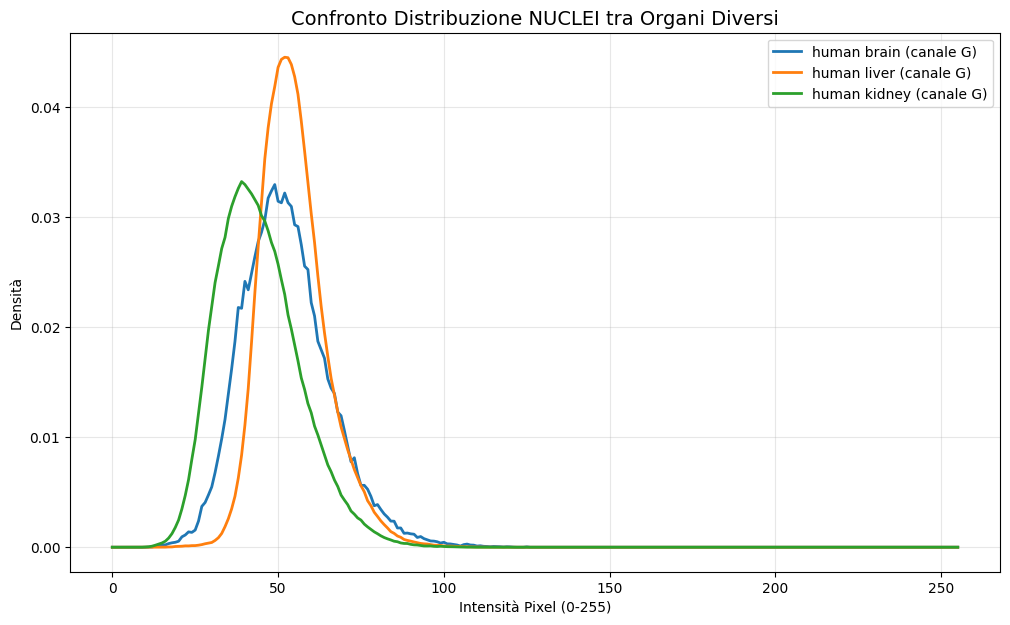

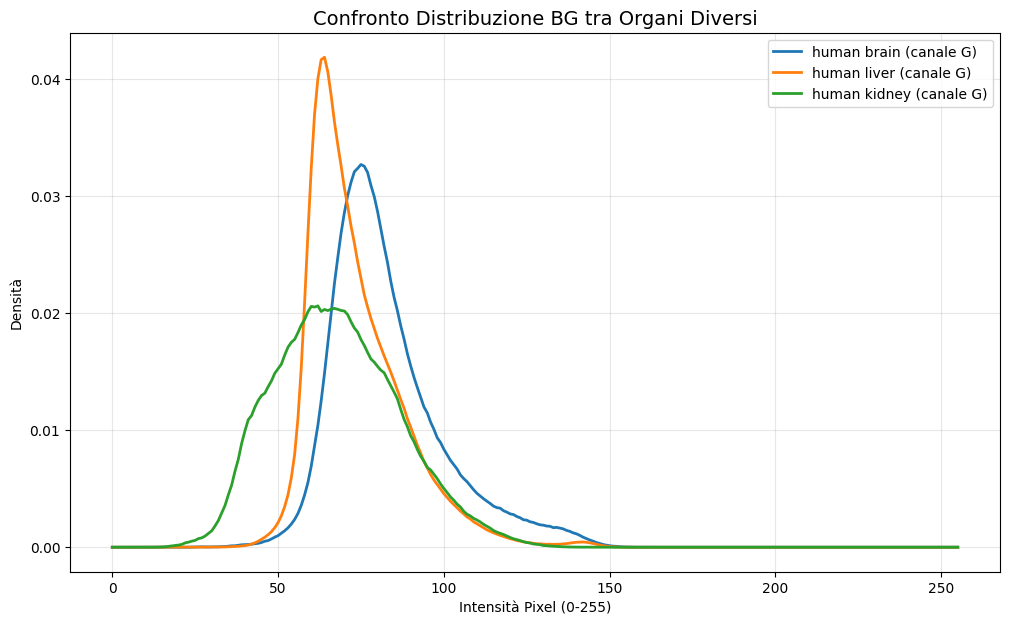

In [45]:
def confronta_organi_specifici(lista_organi, tipo='nuclei'):
    """
    lista_organi: elenco di nomi (es. ['human brain', 'human liver', 'human kidney'])
    tipo: 'nuclei' oppure 'bg' (sfondo)
    """
    plt.figure(figsize=(12, 7))
    
    # Scegliamo di visualizzare solo il canale VERDE (G) 
    # perché è il più rappresentativo dell'Ematossilina nei nuclei
    canale_da_mostrare = 1 # 0=R, 1=G, 2=B
    
    for organo in lista_organi:
        if organo in stats_organi:
            dati = stats_organi[organo][tipo][:, canale_da_mostrare]
            totale = dati.sum() if dati.sum() > 0 else 1
            
            plt.plot(dati / totale, label=f"{organo} (canale G)", lw=2)
        else:
            print(f"⚠️ Organo {organo} non trovato nel dataset.")

    plt.title(f"Confronto Distribuzione {tipo.upper()} tra Organi Diversi", fontsize=14)
    plt.xlabel("Intensità Pixel (0-255)")
    plt.ylabel("Densità")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ESEMPIO: Confronta i nuclei di 3 organi a scelta
confronta_organi_specifici(['human brain', 'human liver', 'human kidney'], tipo='nuclei')

# ESEMPIO: Confronta lo sfondo di 3 organi a scelta
confronta_organi_specifici(['human brain', 'human liver', 'human kidney'], tipo='bg') 